# Calidad de datos y distribuciones (notebook de evidencia)

**Data Analyst · Anastasia Ganderats · Sprint 1**

Este notebook responde con imágenes dos preguntas distintas que suelen confundirse:

1. **¿Hay data sucia?** → integridad: nulos, duplicados, huérfanos, rangos imposibles, tipos.
2. **¿Hay outliers? ¿Qué forma tienen las variables?** → boxplots, percentiles y un chequeo de normalidad.

> **La conclusión** Los datos están **íntegros** (no hay que "limpiar" casi nada), y
> los **valores extremos existen pero son legítimos** (carritos de abastecimiento, usuarios heavy, la
> banana). No son errores: son **señal**. Por eso se **documentan y se conservan**, no se eliminan —
> y como las variables **no son normales**, se describen con **mediana y percentiles**, no media±desvío.


In [1]:
%matplotlib inline
import os
from pathlib import Path
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def _find_root(start):
    for c in [start, *start.parents]:
        if (c/"data"/"raw").exists() or (c/".git").exists():
            return c
    return start
ROOT = _find_root(Path.cwd().resolve())
_env = os.environ.get("INSTACART_DATA")
_cands = ([Path(_env)] if _env else []) + [ROOT/"data"/"raw", ROOT/"dataset", Path("dataset"), Path("data/raw")]
DS = next((p for p in _cands if (p/"orders.csv").exists()), None)
assert DS is not None, "No encuentro los CSV. Ponelos en data/raw/ (o dataset/), o exportá INSTACART_DATA."
FIG = ROOT/"reports"/"figures"; FIG.mkdir(parents=True, exist_ok=True)

con = duckdb.connect(); con.execute("PRAGMA threads=2; PRAGMA memory_limit='2.5GB'; PRAGMA disable_progress_bar;")
for n,f in [("orders","orders.csv"),("prior","order_products__prior.csv"),("products","products.csv"),
            ("aisles","aisles.csv"),("departments","departments.csv")]:
    con.execute(f"CREATE VIEW {n} AS SELECT * FROM read_csv_auto('{DS/f}')")
sql = lambda q: con.execute(q).fetchdf()

# --- Paleta: solo azul / blanco / rojo (sin gris) ---
AZUL, AZUL_OSC, AZUL_MED, AZUL_CLARO = "#12408f", "#0a2a5e", "#2e67c4", "#a9c7ea"
ROJO = "#e4002b"; TINTA, TINTA2 = "#0a2340", "#39568c"; GRILLA, EJE = "#e3ebf6", "#c2d6ef"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
    "font.size":10,"figure.dpi":110,"axes.prop_cycle":plt.cycler(color=[AZUL,ROJO,AZUL_MED,AZUL_CLARO])})
def ejes(ax,titulo="",sub="",xlab="",ylab="",grid="y"):
    for s in ("top","right"): ax.spines[s].set_visible(False)
    for s in ("left","bottom"): ax.spines[s].set_color(EJE)
    ax.tick_params(colors=TINTA2,length=0,labelsize=9)
    if grid: ax.grid(axis=grid,color=GRILLA,linewidth=.9); ax.set_axisbelow(True)
    if xlab: ax.set_xlabel(xlab,color=TINTA2,fontsize=9.5)
    if ylab: ax.set_ylabel(ylab,color=TINTA2,fontsize=9.5)
    if titulo: ax.set_title(titulo,color=TINTA,fontsize=12.5,fontweight="bold",loc="left",pad=18 if sub else 10)
    if sub: ax.text(0,1.015,sub,transform=ax.transAxes,color=TINTA2,fontsize=9.3,va="bottom")
    return ax
def miles(x,pos=None):
    if abs(x)>=1e6: return f"{x/1e6:.1f}M"
    if abs(x)>=1e3: return f"{x/1e3:.0f}k"
    return f"{x:.0f}"
def guardar(fig,n): fig.savefig(FIG/f"{n}.png",dpi=140,bbox_inches="tight"); print("figura →",FIG/f"{n}.png")
print("Datos en:", DS.resolve())

Datos en: C:\dev\instacart-recommender\data\raw


In [2]:
# Agregados por variable (una pasada cada uno; se guardan chicos y se traen a memoria)
con.execute("CREATE OR REPLACE TABLE bo AS SELECT order_id, COUNT(*) v FROM prior GROUP BY order_id")
con.execute("CREATE OR REPLACE TABLE uo AS SELECT user_id, COUNT(*) v FROM orders WHERE eval_set='prior' GROUP BY user_id")
con.execute("CREATE OR REPLACE TABLE pp AS SELECT product_id, COUNT(*) v FROM prior GROUP BY product_id")
con.execute("CREATE OR REPLACE TABLE ur AS SELECT o.user_id, AVG(p.reordered) v FROM prior p JOIN orders o USING(order_id) GROUP BY o.user_id")
carrito   = con.execute("SELECT v FROM bo").fetchdf()["v"].to_numpy()
ordenesxu = con.execute("SELECT v FROM uo").fetchdf()["v"].to_numpy()
popul     = con.execute("SELECT v FROM pp").fetchdf()["v"].to_numpy()
reorder   = con.execute("SELECT v FROM ur").fetchdf()["v"].to_numpy()
VARS = {"Tamaño de carrito":carrito, "Órdenes por usuario":ordenesxu,
        "Popularidad de producto":popul, "Tasa de recompra (usuario)":reorder}
print({k:len(v) for k,v in VARS.items()})

{'Tamaño de carrito': 3214874, 'Órdenes por usuario': 206209, 'Popularidad de producto': 49677, 'Tasa de recompra (usuario)': 206209}


## 1. ¿Hay data sucia? — Integridad

In [3]:
rng = sql("""SELECT
   (SELECT MIN(add_to_cart_order) FROM prior) atc_min, (SELECT MAX(add_to_cart_order) FROM prior) atc_max,
   MIN(order_dow) dow_min, MAX(order_dow) dow_max,
   MIN(order_number) on_min, MAX(order_number) on_max,
   MIN(days_since_prior_order) ds_min, MAX(days_since_prior_order) ds_max FROM orders""").iloc[0]
dup   = int(sql("SELECT COUNT(*)-COUNT(DISTINCT (order_id||'-'||product_id)) d FROM prior")["d"][0])
huerf = int(sql("""SELECT COUNT(*) c FROM (SELECT DISTINCT product_id FROM prior) x
                   LEFT JOIN products USING(product_id) WHERE products.product_id IS NULL""")["c"][0])
dupname = int(sql("SELECT COUNT(*)-COUNT(DISTINCT product_name) d FROM products")["d"][0])
missing = int(sql("""SELECT COUNT(*) c FROM products pr JOIN departments d USING(department_id)
                     JOIN aisles a USING(aisle_id) WHERE d.department='missing' OR a.aisle='missing'""")["c"][0])
hour_tipo = str(con.execute("SELECT typeof(order_hour_of_day) FROM orders LIMIT 1").fetchone()[0])

integridad = pd.DataFrame([
 ["Nulos en claves (order_id, user_id, product_id)", "0", "✔ limpio"],
 ["Nulos en days_since_prior_order", "206.209", "✔ esperado: 1 por usuario (1ª orden). Semántico, no error"],
 ["Pares (orden, producto) duplicados", f"{dup}", "✔ limpio"],
 ["product_id / order_id huérfanos", f"{huerf}", "✔ integridad referencial OK"],
 ["Dominio de reordered", "{0, 1}", "✔ sin valores fuera de dominio"],
 ["Rango add_to_cart_order", f"{rng.atc_min}–{rng.atc_max}", "✔ ≥1, coherente"],
 ["Rango order_dow / order_number", f"0–{rng.dow_max} / 1–{rng.on_max}", "✔ válidos (100 = tope del dataset)"],
 ["Rango days_since_prior_order", f"{rng.ds_min:.0f}–{rng.ds_max:.0f}", "✔ válido (30 = censura '30+')"],
 ["Nombres de producto duplicados", f"{dupname}", "✔ catálogo sin duplicados"],
 [f"Tipo de order_hour_of_day", hour_tipo, "⚠ viene como TEXTO ('08'): castear a entero en el pipeline"],
 ["Productos con categoría 'missing'", f"{missing:,}", "⚠ ~2,5% del catálogo sin depto/pasillo real: degrada features de contenido"],
], columns=["Control","Resultado","Veredicto"])
integridad

,Control,Resultado,Veredicto
0,"Nulos en claves (order_id, user_id, product_id)",0,✔ limpio
1,Nulos en days_since_prior_order,206.209,✔ esperado: 1 por usuario (1ª orden). Semántic...
2,"Pares (orden, producto) duplicados",0,✔ limpio
3,product_id / order_id huérfanos,0,✔ integridad referencial OK
4,Dominio de reordered,"{0, 1}",✔ sin valores fuera de dominio
5,Rango add_to_cart_order,1.0–145.0,"✔ ≥1, coherente"
6,Rango order_dow / order_number,0–6.0 / 1–100.0,✔ válidos (100 = tope del dataset)
7,Rango days_since_prior_order,0–30,✔ válido (30 = censura '30+')
8,Nombres de producto duplicados,0,✔ catálogo sin duplicados
9,Tipo de order_hour_of_day,VARCHAR,⚠ viene como TEXTO ('08'): castear a entero en...


> **→ Veredicto**
>
> **No hay data sucia.** Claves completas, integridad referencial intacta, cero duplicados, todos los
> valores dentro de dominio. Los nulos de `days_since_prior_order` son **semánticos** (primera orden),
> no un error. Solo quedan **dos ítems de higiene** para el pipeline: castear `order_hour_of_day` de
> texto a entero, y marcar los **1.258 productos sin categoría** (`missing`) porque debilitan las
> features de contenido para el cold-start.


## 2. ¿Hay outliers? — Distribuciones, boxplots y percentiles

In [4]:
def resumen(a):
    q1,q3 = np.percentile(a,25), np.percentile(a,75); fence = q3+1.5*(q3-q1)
    return {"min":a.min(),"p50":np.median(a),"p90":np.percentile(a,90),"p95":np.percentile(a,95),
            "p99":np.percentile(a,99),"máx":a.max(),"media":a.mean(),"desvío":a.std(),
            "asimetría":pd.Series(a).skew(),"cerco IQR":fence,"% sobre cerco":(a>fence).mean()*100}
tabla = pd.DataFrame({k:resumen(v) for k,v in VARS.items()}).T
tabla_fmt = tabla.copy()
for c in ["min","p50","p90","p95","p99","máx","media","desvío","cerco IQR"]: tabla_fmt[c]=tabla_fmt[c].round(2)
tabla_fmt["asimetría"]=tabla_fmt["asimetría"].round(2); tabla_fmt["% sobre cerco"]=tabla_fmt["% sobre cerco"].round(1)
tabla_fmt

,min,p50,p90,p95,p99,máx,media,desvío,asimetría,cerco IQR,% sobre cerco
Tamaño de carrito,1.0,8.00,20.00,25.00,35.00,145.00,10.09,7.53,1.56,27.50,3.3
Órdenes por usuario,3.0,9.00,37.00,51.00,88.00,99.00,15.59,16.65,2.40,40.00,8.3
Popularidad de producto,1.0,60.00,1021.00,2286.00,9931.16,472565.00,652.91,4792.07,44.88,624.50,14.3
Tasa de recompra (usuario),0.0,0.43,0.72,0.78,0.86,0.99,0.43,0.21,0.03,1.09,0.0


figura → C:\dev\instacart-recommender\reports\figures\qc_01_boxplots.png


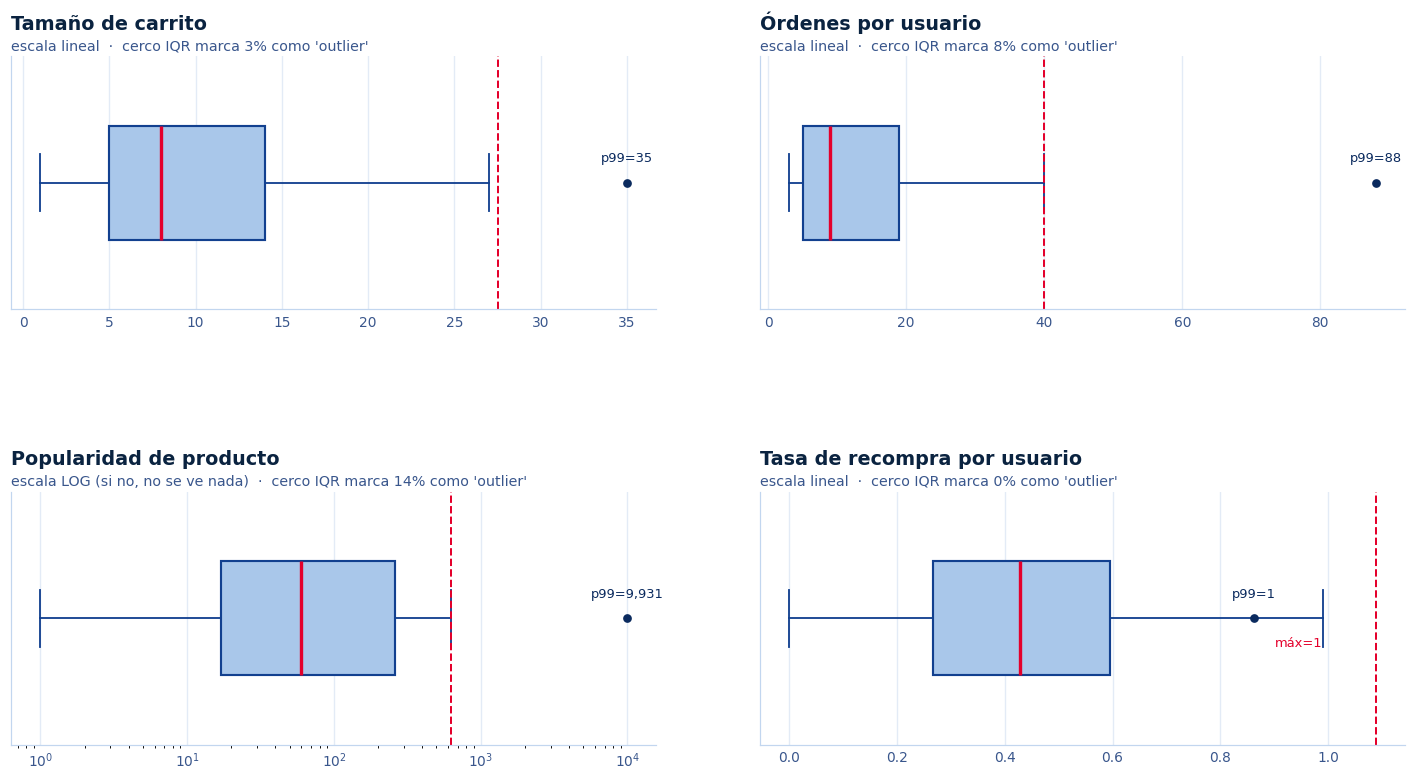

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.2))
def boxplot(ax, a, titulo, sub, logx=False):
    q1,q3 = np.percentile(a,25), np.percentile(a,75); fence = q3+1.5*(q3-q1)
    ax.boxplot(a, vert=False, showfliers=False, widths=.45, patch_artist=True,
               boxprops=dict(facecolor=AZUL_CLARO, edgecolor=AZUL, linewidth=1.4),
               medianprops=dict(color=ROJO, linewidth=2.2),
               whiskerprops=dict(color=AZUL, linewidth=1.2), capprops=dict(color=AZUL, linewidth=1.2))
    if logx: ax.set_xscale("log")
    ax.axvline(fence, color=ROJO, linestyle="--", linewidth=1.3)
    p99, mx = np.percentile(a,99), a.max()
    ax.scatter([p99],[1], color=AZUL_OSC, zorder=5, s=22)
    ax.annotate(f"p99={p99:,.0f}", (p99,1), xytext=(0,14), textcoords="offset points",
                ha="center", color=AZUL_OSC, fontsize=8.5)
    ax.annotate(f"máx={mx:,.0f}", (mx,1), xytext=(0,-18), textcoords="offset points",
                ha="right", color=ROJO, fontsize=8.5)
    pct=(a>fence).mean()*100
    ejes(ax, titulo, sub+f"  ·  cerco IQR marca {pct:.0f}% como 'outlier'", grid="x")
    ax.set_yticks([])
boxplot(axes[0,0], carrito,   "Tamaño de carrito", "escala lineal")
boxplot(axes[0,1], ordenesxu, "Órdenes por usuario", "escala lineal")
boxplot(axes[1,0], popul,     "Popularidad de producto", "escala LOG (si no, no se ve nada)", logx=True)
boxplot(axes[1,1], reorder,   "Tasa de recompra por usuario", "escala lineal")
plt.tight_layout(); plt.subplots_adjust(hspace=0.72, wspace=0.16)
guardar(fig, "qc_01_boxplots"); plt.show()

> **→ Interpretación (clave)**
>
> El cerco de Tukey (IQR) marcaría como "outliers" el **3%** de los carritos, **8%** de los usuarios y
> hasta **14%** de los productos. **No son errores:** son compras de abastecimiento, clientes fieles y
> los productos estrella (la banana llega a **472.565** compras vs. una mediana de **60**). Borrarlos
> **destruiría** la señal del recomendador. Decisión: **se conservan**; las features se **normalizan
> por tamaño de carrito** para que los extremos no dominen.


## 3. ¿Son normales? — Chequeo de forma

figura → C:\dev\instacart-recommender\reports\figures\qc_02_normalidad.png


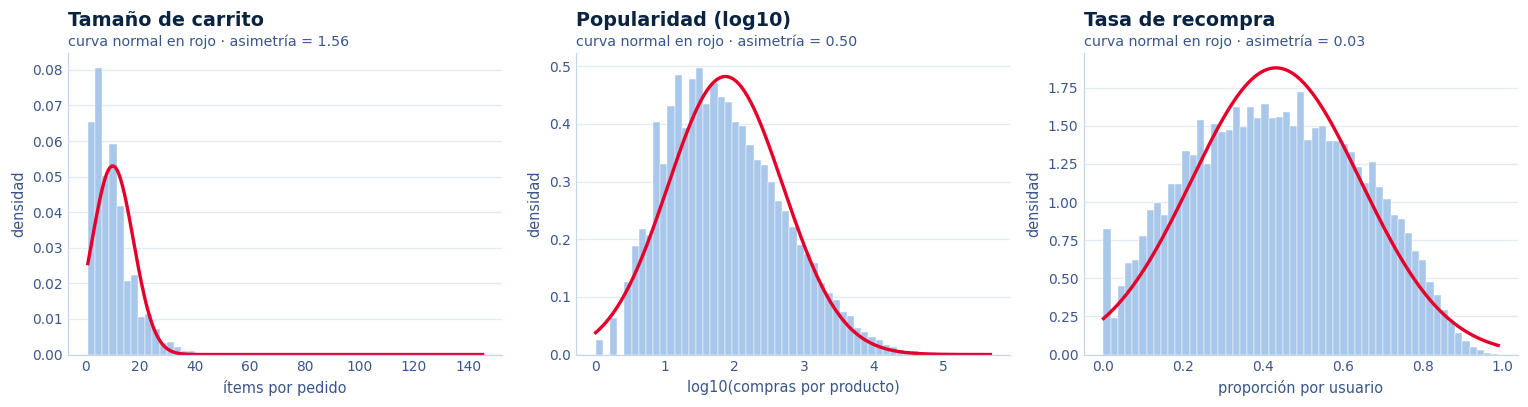

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
def hist_normal(ax, a, titulo, xlab, logx=False):
    d = np.log10(a) if logx else a.astype(float)
    ax.hist(d, bins=55, density=True, color=AZUL_CLARO, edgecolor="white", linewidth=.3)
    mu, sd = d.mean(), d.std()
    xs = np.linspace(d.min(), d.max(), 250)
    ax.plot(xs, np.exp(-0.5*((xs-mu)/sd)**2)/(sd*np.sqrt(2*np.pi)), color=ROJO, linewidth=2.2)
    sk = pd.Series(d).skew()
    ejes(ax, titulo, f"curva normal en rojo · asimetría = {sk:.2f}", xlab=xlab, ylab="densidad")
    return sk
hist_normal(axes[0], carrito, "Tamaño de carrito", "ítems por pedido")
hist_normal(axes[1], popul,   "Popularidad (log10)", "log10(compras por producto)", logx=True)
hist_normal(axes[2], reorder, "Tasa de recompra", "proporción por usuario")
plt.tight_layout(); guardar(fig, "qc_02_normalidad"); plt.show()

> **→ Conclusión sobre la forma**
>
> - **Tamaño de carrito:** sesgado a la derecha (asimetría ≈ 1,6). No es normal.
> - **Popularidad:** en escala cruda la asimetría es **≈ 45** (extrema); en **log10** se ve casi
>   simétrica → es aproximadamente **log-normal**, no normal. Por eso siempre se grafica en log.
> - **Tasa de recompra:** es la **única** casi simétrica (asimetría ≈ 0,03), pero está acotada en
>   [0, 1], así que tampoco es una normal de manual.
>
> Consecuencia metodológica: **describir con mediana y percentiles**, no con media ± desvío; y **no
> aplicar reglas de outliers basadas en normalidad** (z-score, 3σ), que aquí darían falsos positivos
> masivos.


## 4. Decisión sobre limpieza y outliers

| Variable / tema | Qué muestran los datos | Decisión |
|---|---|---|
| Carritos grandes (hasta 145 ítems) | Reales: compras de abastecimiento | **Conservar**; normalizar features por tamaño de carrito |
| Usuarios heavy (hasta ~100 órdenes) | Reales; el 100 es tope del dataset | **Conservar**; no recortar el techo, documentarlo |
| Productos muy populares (banana: 472k) | Reales; es el sesgo de popularidad | **Conservar**; medir **cobertura** además de Recall |
| days_since_prior_order = 30 | Censura ("30 o más") | Tratar como **censurado**, no como valor exacto |
| days_since_prior_order nulo | 1ª orden de cada usuario | Indicador **es_primera_orden**, no imputar |
| order_hour_of_day (texto) | Viene como '08' (string) | **Castear a entero** en el pipeline |
| 1.258 productos 'missing' | Sin depto/pasillo real (~2,5%) | **Marcar**; degradan features de contenido/cold-start |

**En una frase:** no hay data sucia que limpiar; hay **extremos legítimos que se documentan y conservan**,
y dos ajustes de tipo/categoría para el pipeline. Eliminar "outliers" acá sería un error metodológico.

---
*Notebook de evidencia · DuckDB + pandas · figuras en `figuras/` (prefijo `qc_`).*


In [7]:
con.close(); print("Listo.")

Listo.
